In [1]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

from optical.surface import WaterSruface
from optical.quartic_solver.feralli import solve_quartic_ferrari
from optical.quartic_solver.newton_method import solve_quartic_newton

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Choose dataset by flag or name
dataset_flag = "river2"  # Change this flag to "river1" or "river2" as needed
home_dir = os.path.expanduser("~")

if dataset_flag == "river1":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_with-refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_wo-refraction"))
    non_refraction_model_path = os.path.abspath("../../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply")
elif dataset_flag == "river2":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/refraction"))
    non_refraction_model_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction_wo_plane/cut_sphere.ply"))
else:
    raise ValueError(f"Unknown dataset flag: {dataset_flag}")

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.


In [3]:
data = dataloader_ref.dataset[80]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 

# camtoworlds = torch.Tensor(
#     [[
#         [1, 0, 0, 0],
#         [0, 1, 0, 0],
#         [0, 0, 1, 100],
#         [0, 0, 0, 1]
#     ]]
# ).to(device)  


worldtocam = camtoworlds.inverse()
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)

('train', '0080.png')


In [4]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]

In [5]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSruface(
    means=means,
    quats=quats,
    scales=scales,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=False,
)

trandformed_means, trandformed_quats = WS.transform_to_appearance()
transformed_scales = WS.scale_correction()






In [6]:
# WO POSIRION, ROTATION, SCALE CORRECTION
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [7]:
# WITH POSITOIN< ROTATION, WO SCALE CORRECTION
rgb_refraction_wo_scale_correction, _, _ = rasterization(
    trandformed_means,
    trandformed_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_wo_scale_correction = rgb_refraction_wo_scale_correction.squeeze().cpu().detach().numpy()

In [8]:
# WITH POSITION, ROTATION, SCALE CORRECTION
rgb_refraction_with_scale_correction, _, _ = rasterization(
    trandformed_means,
    trandformed_quats,
    transformed_scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_with_scale_correction = rgb_refraction_with_scale_correction.squeeze().cpu().detach().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0618446].


GT image without refraction: /home/taiki/dataset/river2/wo_refraction/train/0080.png
GT image with refraction: /home/taiki/dataset/river2/refraction/train/0080.png


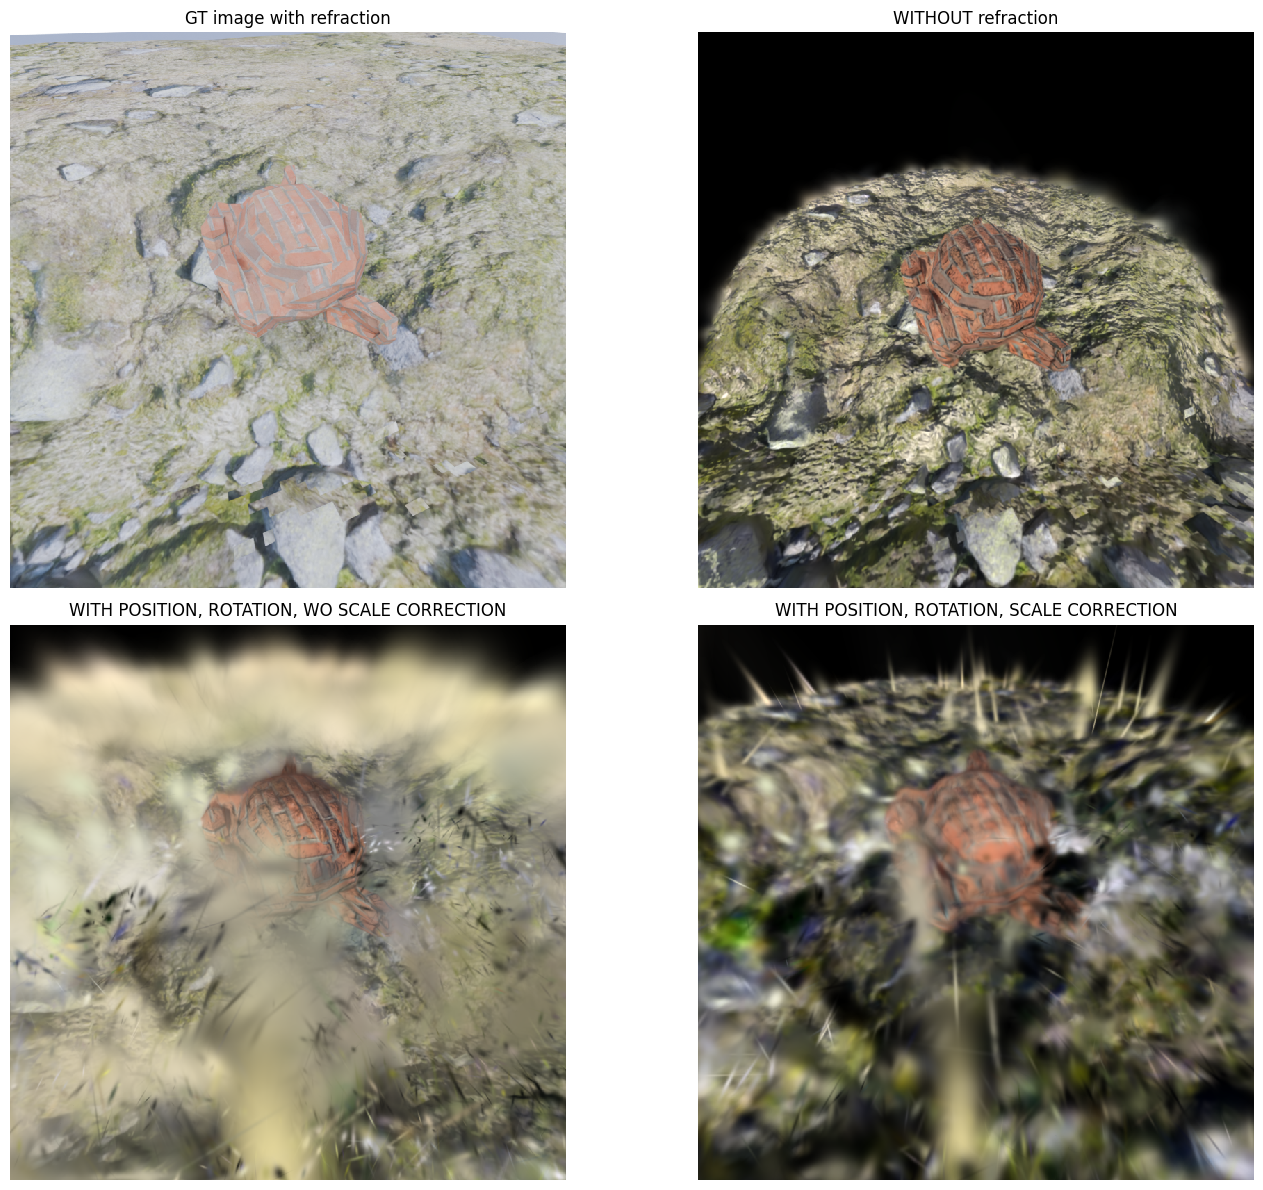

In [9]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_with_ref)
ax[0, 0].set_title("GT image with refraction")
ax[0, 1].imshow(rgb_wo_refraction)
ax[0, 1].set_title("WITHOUT refraction")
ax[1, 0].imshow(rgb_refraction_wo_scale_correction)
ax[1, 0].set_title("WITH POSITION, ROTATION, WO SCALE CORRECTION")
ax[1, 1].imshow(rgb_refraction_with_scale_correction)
ax[1, 1].set_title("WITH POSITION, ROTATION, SCALE CORRECTION")
ax[0, 0].axis("off")
ax[0, 1].axis("off")
ax[1, 0].axis("off")
ax[1, 1].axis("off")
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.083944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0894129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0618446].


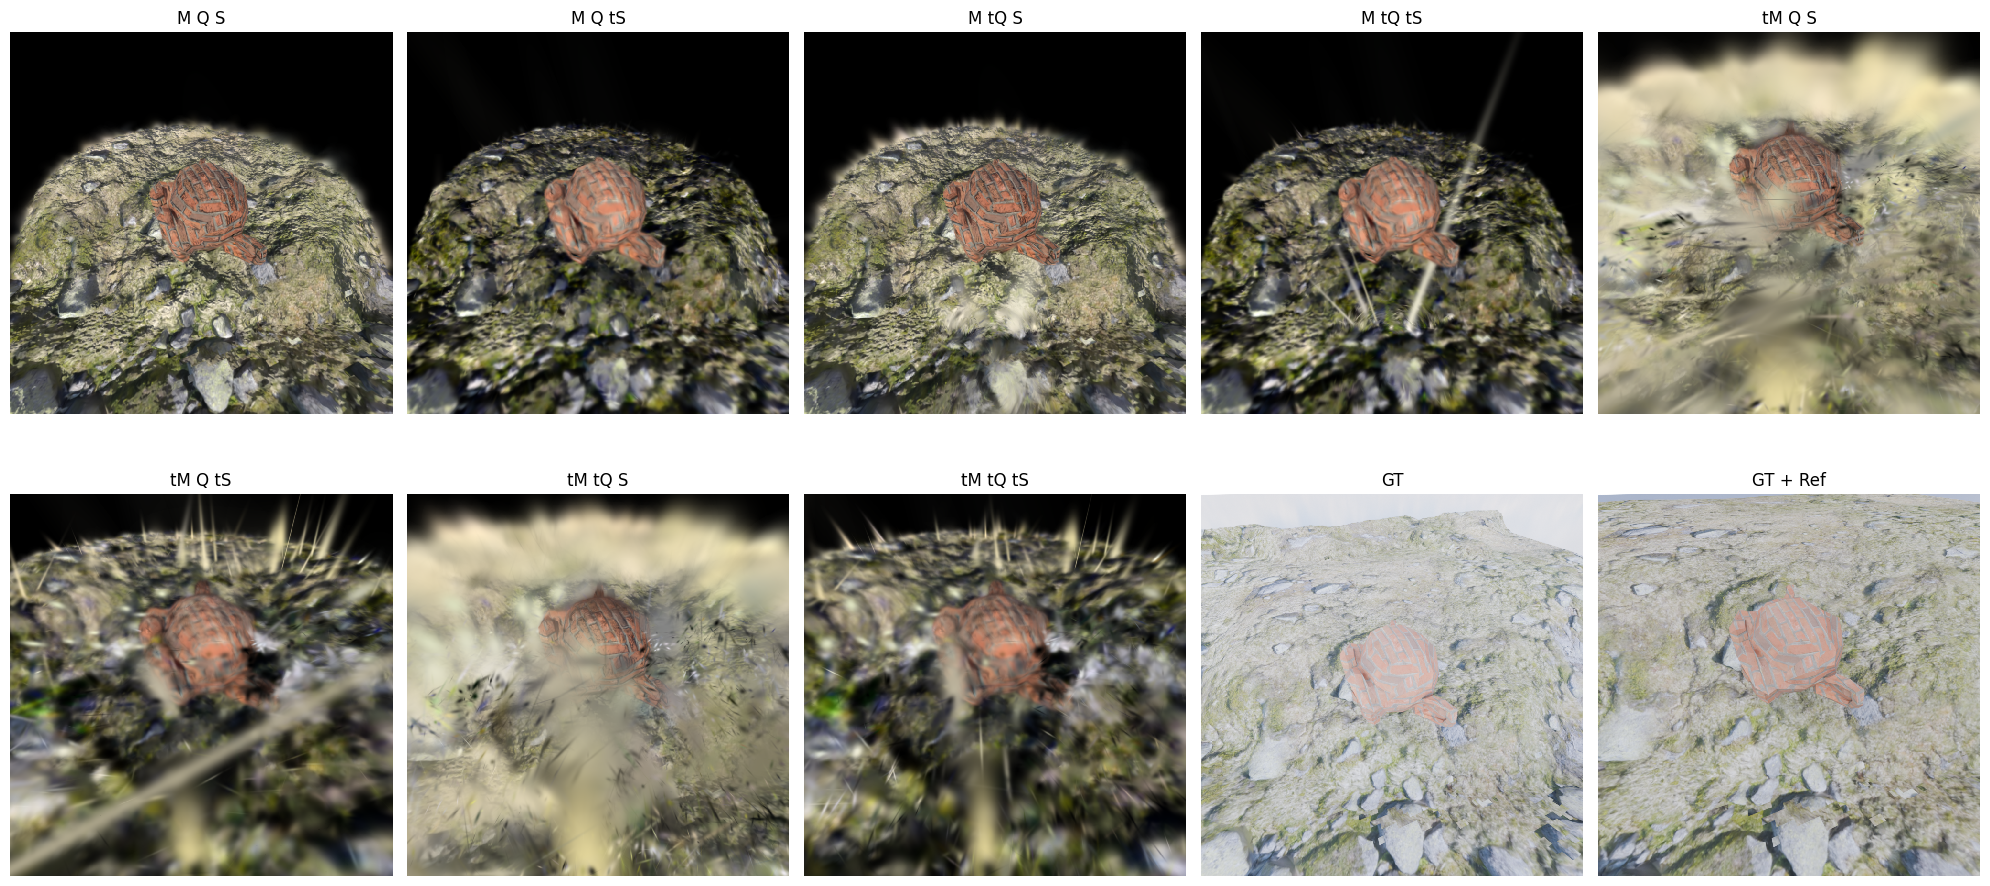

In [ ]:
import itertools

# Compare all 8 combinations of original vs transformed means, quats, scales

# prepare figure
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# binary choices for (means, quats, scales)
choices = list(itertools.product([False, True], repeat=3))
for idx, (use_t_mean, use_t_quat, use_t_scale) in enumerate(choices):
    m = trandformed_means    if use_t_mean  else means
    q = trandformed_quats    if use_t_quat  else quats
    s = transformed_scales    if use_t_scale else scales

    # rasterize
    rgb, _, _ = rasterization(
        m, q, s,
        opacities, colors,
        worldtocam, Ks,
        width, height,
        sh_degree=0,
        rasterize_mode="antialiased"
    )
    img = rgb.squeeze().detach().cpu().numpy()

    # title
    title = []
    title.append("tM" if use_t_mean  else "M")
    title.append("tQ" if use_t_quat  else "Q")
    title.append("tS" if use_t_scale else "S")
    axes[idx].imshow(img)
    axes[idx].set_title(" ".join(title))
    axes[idx].axis("off")

plt.tight_layout()
plt.show()